## GitHub 연동

아래 코드를 실행해주세요.


In [2]:
cd /content/drive/MyDrive/dataScience/datascience/

/content/drive/MyDrive/dataScience/datascience


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!git config --global user.email 'jinjins0629@gmail.com'
!git config --global user.name 'ohhu-code'

In [5]:
!git status

Refresh index: 100% (5/5), done.
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	Lab5.ipynb

nothing added to commit but untracked files present (use "git add" to track)


In [6]:
!git pull origin main

From https://github.com/ohhu-code/datascience
 * branch            main       -> FETCH_HEAD
Already up to date.


In [7]:
import pandas as pd
exam_xls = pd.read_excel('/content/drive/MyDrive/dataScience/excel_exam.xlsx')
print(exam_xls)

    id  nclass  math  english  science
0    1       1    50       98       50
1    2       1    60       97       60
2    3       1    45       86       78
3    4       1    30       98       58
4    5       2    25       80       65
5    6       2    50       89       98
6    7       2    80       90       45
7    8       2    90       78       25
8    9       3    20       98       15
9   10       3    50       98       45
10  11       3    65       65       65
11  12       3    45       85       32
12  13       4    46       98       65
13  14       4    48       87       12
14  15       4    75       56       78
15  16       4    58       98       65
16  17       5    65       68       98
17  18       5    80       78       90
18  19       5    89       68       87
19  20       5    78       83       58


# Lab08



Observing a dataset

In [25]:
import pandas as pd
exam2 = pd.read_csv('/content/drive/MyDrive/dataScience/exam2.csv')
print(exam2.head(20))

    id  nclass  math  english  science
0    1       1  50.0     98.0     50.0
1    2       1  60.0     97.0     60.0
2    3       1  45.0     86.0     78.0
3    4       1  30.0      NaN     58.0
4    5       2  25.0     80.0     65.0
5    6       2  50.0     89.0     98.0
6    7       2  80.0     90.0     45.0
7    8       2   NaN     78.0     25.0
8    9       3  20.0     98.0     15.0
9   10       3  50.0     98.0     45.0
10  11       3  65.0     65.0     65.0
11  12       3  45.0     85.0     32.0
12  13       4  46.0      NaN     65.0
13  14       4  48.0     87.0     12.0
14  15       4  75.0     56.0     78.0
15  16       4  58.0     98.0     65.0
16  17       5  65.0     68.0      NaN
17  18       5  80.0      NaN     90.0
18  19       5  89.0     68.0     87.0
19  20       5  78.0     83.0     58.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       20 non-null     int64  
 1   nclass   20 non-null     int64  
 2   math     19 non-null     float64
 3   english  17 non-null     float64
 4   science  19 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 932.0 bytes


array([[<Axes: title={'center': 'math'}>,
        <Axes: title={'center': 'english'}>,
        <Axes: title={'center': 'science'}>, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

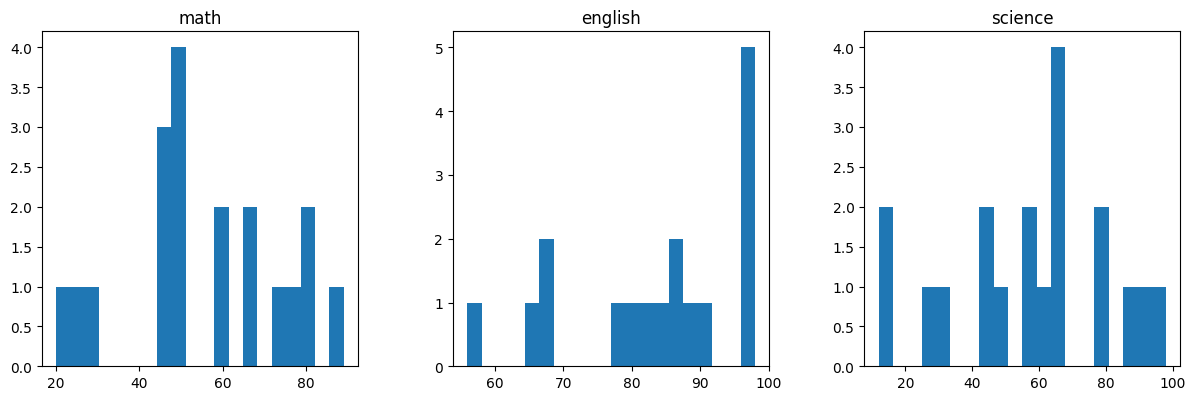

In [55]:
import pandas as pd

exam2 = pd.read_csv('/content/drive/MyDrive/dataScience/exam2.csv')
exam2.info()

exam2.iloc[:, 2:].hist(figsize=(20,10), grid=False, layout=(2,4), bins=20)
# 숫자 인덱스 기반으로 행/열을 선택하는 함수. 정수 위치를 넣어줘야 해.

In [47]:
exam2.info()
pd.isna(exam2).sum()
# pd.isna(exam2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       20 non-null     int64  
 1   nclass   20 non-null     int64  
 2   math     19 non-null     float64
 3   english  17 non-null     float64
 4   science  19 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 932.0 bytes


,0
id,0
nclass,0
math,1
english,3
science,1


df.mode()
▪ the most frequently occurring value for each column.
▪ Because mode() returns a dataframe, you need to use asbelow to get only the frequency of value.

In [33]:
freq = exam2.mode()
print(freq.head(1))

   id  nclass  math  english  science
0   1     1.0  50.0     98.0     65.0


Lab (Missing values, Outliers) 1/3

In [18]:
import pandas as pd
import numpy as np
data = {
'나이': [25, 32, None, 45, 28, 35, 99, 30, 22, 41],
'성별': ['남','여','남','여','남', None,'여','남','여','남'],
'키(cm)': [175.5, 162.0, 180.1, 168.5, 172.3, 178.0, 165.0, 170.0, None, 171.2],
'구매_금액(만원)': [10, 3, 5, 8, 4, 12, 7, 6, 150, 7] }

df = pd.DataFrame(data)

# CSV 파일로 저장
file_name = 'sample_data_with_issues.csv'
df.to_csv(file_name, index=False, encoding='utf-8')

# 1. CSV 파일 읽어오기
file_name = 'sample_data_with_issues.csv'
try:
  df = pd.read_csv(file_name, encoding='utf-8')
  print("--- 1. Original Dataframe ---")
  print()
  display(df)
  print("\n결측치 수량:\n", df.isnull().sum())
except FileNotFoundError:
  print(f"오류: {file_name} 파일을 찾을 수 없습니다. 파일을 먼저 생성해주세요.")
  exit()


# --- 2. Missing Values Imputation ---
# A. '성별' (Categorical Data) Missing values: Replace with mode (‘남’)
most_frequent_gender = df['성별'].mode()[0]
df['성별'] = df['성별'].fillna(most_frequent_gender)
# B. '나이' 및'키(cm)' 결측치: Replace with mean or median
# Use median to reduce the impact of outliers.
df['나이'] = df['나이'].fillna(df['나이'].median())
df['키(cm)'] = df['키(cm)'].fillna(df['키(cm)'].median())
print("\n--- 2. after handling Missing Values ---")
print()
print(df.info())
print()

--- 1. Original Dataframe ---



,나이,성별,키(cm),구매_금액(만원)
0,25.0,남,175.5,10
1,32.0,여,162.0,3
2,NaN,남,180.1,5
3,45.0,여,168.5,8
4,28.0,남,172.3,4
5,35.0,NaN,178.0,12
6,99.0,여,165.0,7
7,30.0,남,170.0,6
8,22.0,여,NaN,150
9,41.0,남,171.2,7



결측치 수량:
 나이           1
성별           1
키(cm)        1
구매_금액(만원)    0
dtype: int64

--- 2. after handling Missing Values ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   나이         10 non-null     float64
 1   성별         10 non-null     object 
 2   키(cm)      10 non-null     float64
 3   구매_금액(만원)  10 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 452.0+ bytes
None



In [19]:
# 3. Outlier Handling ---
# A: Age over 80 is considered an outlier and the row is removed.
print("Outliers (age >=80)")
print(df[df['나이'] >= 80])
print("after handling Outliers")
df = df[df['나이'] < 80]

# B: Use the IQR to replace the ‘구매금액(만원)' outlier with the upper limit
Q1 = df['구매_금액(만원)'].quantile(0.25)
Q3 = df['구매_금액(만원)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print('lower_bound =', lower_bound)
print('upper_bound =', upper_bound)

# Replace outliers that exceed the upper limit with the upper limit value
df['구매_금액(만원)'] = df['구매_금액(만원)'].apply(lambda x: upper_bound if x > upper_bound else x)
print()
print(f"\n--- 3. after handling Missing values and Outliers ---")
print(df)

Outliers (age >=80)
     나이 성별  키(cm)  구매_금액(만원)
6  99.0  여  165.0          7
after handling Outliers
lower_bound = -2.5
upper_bound = 17.5


--- 3. after handling Missing values and Outliers ---
     나이 성별  키(cm)  구매_금액(만원)
0  25.0  남  175.5       10.0
1  32.0  여  162.0        3.0
2  32.0  남  180.1        5.0
3  45.0  여  168.5        8.0
4  28.0  남  172.3        4.0
5  35.0  남  178.0       12.0
7  30.0  남  170.0        6.0
8  22.0  여  171.2       17.5
9  41.0  남  171.2        7.0


Merge data – merge() 1/2
▪ This is an example of combining customer information and order
information based on "customer ID".

In [13]:
import pandas as pd

print("1. 고객 데이터 (Left Table)")

df_customers = pd.DataFrame({
  'customer_id': [101, 102, 103],
  'name': ['Kim', 'Lee', 'Park']
})
print(df_customers)
print()
print("2. 주문 데이터 (Right Table)")

df_orders = pd.DataFrame({
  'order_id': [1, 2, 3],
  'customer_id': [101, 102, 105], # Number 105 is not in customer data
  'product': ['Laptop', 'Mouse', 'Keyboard']
})
print(df_orders)
print()

1. 고객 데이터 (Left Table)
   customer_id  name
0          101   Kim
1          102   Lee
2          103  Park

2. 주문 데이터 (Right Table)
   order_id  customer_id   product
0         1          101    Laptop
1         2          102     Mouse
2         3          105  Keyboard



In [20]:
print("Inner Join: 양쪽에 모두 존재하는 데이터만 결합")
inner_merge = pd.merge(df_customers, df_orders, on='customer_id', how='inner')

print(inner_merge)
print()

print("Left Join: 왼쪽(고객) 기준, 주문 없는 고객은 NaN 처리")
left_merge = pd.merge(df_customers, df_orders, on='customer_id', how='left')

print(left_merge)
print()

print("Right Join: 오른쪽(주문) 기준, 주문 없는 고객은 NaN 처리")
right_merge = pd.merge(df_customers, df_orders, on='customer_id', how='right')

print(right_merge)

Inner Join: 양쪽에 모두 존재하는 데이터만 결합
   customer_id name  order_id product
0          101  Kim         1  Laptop
1          102  Lee         2   Mouse

Left Join: 왼쪽(고객) 기준, 주문 없는 고객은 NaN 처리
   customer_id  name  order_id product
0          101   Kim       1.0  Laptop
1          102   Lee       2.0   Mouse
2          103  Park       NaN     NaN

Right Join: 오른쪽(주문) 기준, 주문 없는 고객은 NaN 처리
   customer_id name  order_id   product
0          101  Kim         1    Laptop
1          102  Lee         2     Mouse
2          105  NaN         3  Keyboard


Changing the dataframe structure(melt)

In [22]:
# 1. Wide Format Data (Horizontally long data)
df_wide = pd.DataFrame({
'Year': [2023, 2024],
'Jan': [100, 150],
'Feb': [120, 180],
'Mar': [160, 170]
})
# 2. melt: Lengthen horizontal data vertically (For Analysis/Visualization)
df_long = df_wide.melt(id_vars='Year', var_name='Month', value_name='Sales')

# 3. pivot_table: Recreate a summary table (for reports)
df_pivot = df_long.pivot_table(index='Month', columns='Year', values='Sales',
aggfunc='mean')
print(df_wide)
print()
print(df_long)
print()
print(df_pivot)

   Year  Jan  Feb  Mar
0  2023  100  120  160
1  2024  150  180  170

   Year Month  Sales
0  2023   Jan    100
1  2024   Jan    150
2  2023   Feb    120
3  2024   Feb    180
4  2023   Mar    160
5  2024   Mar    170

Year    2023   2024
Month              
Feb    120.0  180.0
Jan    100.0  150.0
Mar    160.0  170.0


### Git Upload

In [ ]:
!git add .
!git commit -m "Lab6/Pandas 실습"

[main 2bc48e7] Lab6/Pandas 실습
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite Lab3.ipynb (90%)


In [ ]:
!git push

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 824 bytes | 103.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/ohhu-code/datascience.git
   e0de745..2bc48e7  main -> main


In [ ]:
!git pull origin main

From https://github.com/ohhu-code/datascience
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
